This script correlates meta data (AST and ALT) with the TOO deconvolution results. The biochemical data (ALT and AST) were kindly provided by the authors of the study.


In [1]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load & clean metadata
# -----------------------------
meta = pd.read_csv("Chalasani_ALT_AST.csv")

# Normalize column names & fix typos
meta = meta.rename(columns=lambda x: str(x).strip())
if "SAMLPE ID" in meta.columns:
    meta = meta.rename(columns={"SAMLPE ID": "Sample_ID"})
elif "SAMPLE ID" in meta.columns:
    meta = meta.rename(columns={"SAMPLE ID": "Sample_ID"})

# Force ID as string
meta["Sample_ID"] = meta["Sample_ID"].astype(str).str.strip()

# Convert ALT/AST to numeric ("None" → NaN)
meta["ALT"] = pd.to_numeric(meta.get("ALT"), errors="coerce")
meta["AST"] = pd.to_numeric(meta.get("AST"), errors="coerce")

# -----------------------------
# 2) Map Sample_ID -> SRR (Run)
# -----------------------------
sra = pd.read_csv("PRJNA701722_SraRunTable.csv", dtype={"Run": str, "Sample Name": str})
sra["Sample_num"] = sra["Sample Name"].str.split("-").str[0].astype(str).str.strip()

# Merge metadata with SRA
meta = meta.merge(sra[["Run", "Sample_num"]], left_on="Sample_ID", right_on="Sample_num", how="left")
meta = meta.rename(columns={"Run": "SRR"})
print(f"Metadata rows with SRR mapping: {meta['SRR'].notna().sum()} / {len(meta)}")

# -----------------------------
# 3) Setup output directory
# -----------------------------
base_out = "Results_Spearman-Corr"
os.makedirs(base_out, exist_ok=True)

# -----------------------------
# Helper: correlation + plotting
# -----------------------------
def run_corr_and_plot(df_tool, cohort, tool, biomarker, out_dir, results):
    # Drop missing biomarker values
    df_bm = df_tool.dropna(subset=[biomarker]).copy()
    if df_bm.shape[0] < 3:
        return results  # skip if too few samples

    liver = pd.to_numeric(df_bm["Liver"], errors="coerce")
    marker = pd.to_numeric(df_bm[biomarker], errors="coerce")

    mask_valid = liver.notna() & marker.notna()
    df_bm = df_bm.loc[mask_valid]
    liver = liver.loc[mask_valid]
    marker = marker.loc[mask_valid]

    if df_bm.shape[0] < 3:
        return results

    # Spearman correlation
    rho, p_rho = spearmanr(liver, marker)

    # Pearson correlation (log1p)
    marker_log = np.log1p(marker)
    r, p_r = pearsonr(liver, marker_log)

    results.append({
        "Cohort": cohort,
        "DeconvolutionTool": tool,
        "Biomarker": biomarker,
        "N": int(df_bm.shape[0]),
        "Spearman_rho": float(rho),
        "Spearman_p": float(p_rho),
        "Pearson_r_log1p": float(r),
        "Pearson_p_log1p": float(p_r),
    })

    # -------- Linear plot --------
    plt.figure(figsize=(8, 6))
    sns.regplot(
        x=marker, y=liver,
        scatter_kws={'s': 30, 'alpha': 0.5, 'color': '#4C72B0'},
        line_kws={'color': 'crimson', 'lw': 2}
    )
    plt.xlabel(f'{biomarker} (U/L)', fontsize=14, fontweight='bold')
    plt.ylabel('Liver contribution (%)', fontsize=14, fontweight='bold')
    plt.title(f'{cohort} | {tool}\nLiver vs {biomarker} ρ={rho:.2f}, p={p_rho:.2e} (n={len(df_bm)})',
              fontsize=16, fontweight='bold')
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    sns.despine()
    plt.tight_layout()
    base = f"{cohort}_{tool}_{biomarker}_linear"
    plt.savefig(os.path.join(out_dir, f"{base}.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(out_dir, f"{base}.pdf"), dpi=300, bbox_inches="tight")
    plt.close()

    # -------- Log-x plot --------
    pos_mask = marker > 0
    if pos_mask.sum() >= 3:
        plt.figure(figsize=(8, 6))
        sns.regplot(
            x=marker[pos_mask], y=liver[pos_mask],
            scatter_kws={'s': 30, 'alpha': 0.5, 'color': '#4C72B0'},
            line_kws={'color': 'crimson', 'lw': 2}
        )
        plt.xscale("log")
        plt.xlabel(f'{biomarker} (U/L, log scale)', fontsize=14, fontweight='bold')
        plt.ylabel('Liver contribution (%)', fontsize=14, fontweight='bold')
        plt.title(f'{cohort} | {tool}\nLiver vs {biomarker} (log x) ρ={rho:.2f}, p={p_rho:.2e} (n={pos_mask.sum()})',
                  fontsize=16, fontweight='bold')
        plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        sns.despine()
        plt.tight_layout()
        base = f"{cohort}_{tool}_{biomarker}_logx"
        plt.savefig(os.path.join(out_dir, f"{base}.png"), dpi=300, bbox_inches="tight")
        plt.savefig(os.path.join(out_dir, f"{base}.pdf"), dpi=300, bbox_inches="tight")
        plt.close()

    return results

# -----------------------------
# 4) Per-cohort analysis
# -----------------------------
decon_files = glob.glob("Decon-Results_Chalasani*/merged_normalised_results.txt")
results = []
all_merged = []

for f in decon_files:
    cohort_dir = os.path.basename(os.path.dirname(f))
    cohort = cohort_dir.replace("Decon-Results_Chalasani_", "").strip()
    out_dir = os.path.join(base_out, cohort)
    os.makedirs(out_dir, exist_ok=True)

    decon = pd.read_csv(f, sep="\t", index_col=0).reset_index().rename(columns={"index": "SRR"})
    decon.columns = decon.columns.str.strip()

    merged = decon.merge(meta, on="SRR", how="inner")
    merged["Cohort"] = cohort
    all_merged.append(merged)

    print(f"[{cohort}] matched SRR rows (before biomarker filtering): {len(merged)}")

    for tool, df_tool in merged.groupby("DeconvolutionTool", dropna=False):
        for biomarker in ["ALT", "AST"]:
            results = run_corr_and_plot(df_tool, cohort, tool, biomarker, out_dir, results)

# -----------------------------
# 5) All patients combined
# -----------------------------
all_df = pd.concat(all_merged, ignore_index=True)
out_dir = os.path.join(base_out, "All")
os.makedirs(out_dir, exist_ok=True)
print(f"[All] matched SRR rows (before biomarker filtering): {len(all_df)}")

for tool, df_tool in all_df.groupby("DeconvolutionTool", dropna=False):
    for biomarker in ["ALT", "AST"]:
        results = run_corr_and_plot(df_tool, "All", tool, biomarker, out_dir, results)

# -----------------------------
# 6) Save summary
# -----------------------------
summary = pd.DataFrame(results).sort_values(["Cohort", "DeconvolutionTool", "Biomarker"])
summary.to_csv(os.path.join(base_out, "ALT_AST_Liver_correlations.csv"), sep="\t", index=False)
print("\nCorrelation summary:")
print(summary)

# -----------------------------
# 7) Prepare dfs for MWU analysis
# -----------------------------
cohort_dfs = {
    "Healthy": [df for df in all_merged if df["Cohort"].iloc[0] == "Healthy"][0],
    "NAFLD":   [df for df in all_merged if df["Cohort"].iloc[0] == "NAFLD"][0],
    "NASH":    [df for df in all_merged if df["Cohort"].iloc[0] == "NASH"][0],
    "All":     all_df
}

Metadata rows with SRR mapping: 948 / 949
[Healthy] matched SRR rows (before biomarker filtering): 280
[NAFLD] matched SRR rows (before biomarker filtering): 630
[NASH] matched SRR rows (before biomarker filtering): 2184
[All] matched SRR rows (before biomarker filtering): 3094

Correlation summary:
     Cohort DeconvolutionTool Biomarker    N  Spearman_rho    Spearman_p  \
42      All        BayesPrism       ALT  355      0.395656  9.420797e-15   
43      All        BayesPrism       AST  355      0.381724  9.271201e-14   
44      All        CIBERSORTx       ALT  355      0.395201  1.016867e-14   
45      All        CIBERSORTx       AST  355      0.364344  1.384707e-12   
46      All             MuSiC       ALT  355      0.252025  1.512091e-06   
47      All             MuSiC       AST  355      0.261912  5.585235e-07   
48      All              NNLS       ALT  355      0.387490  3.646343e-14   
49      All              NNLS       AST  355      0.323478  4.322942e-10   
50      All    

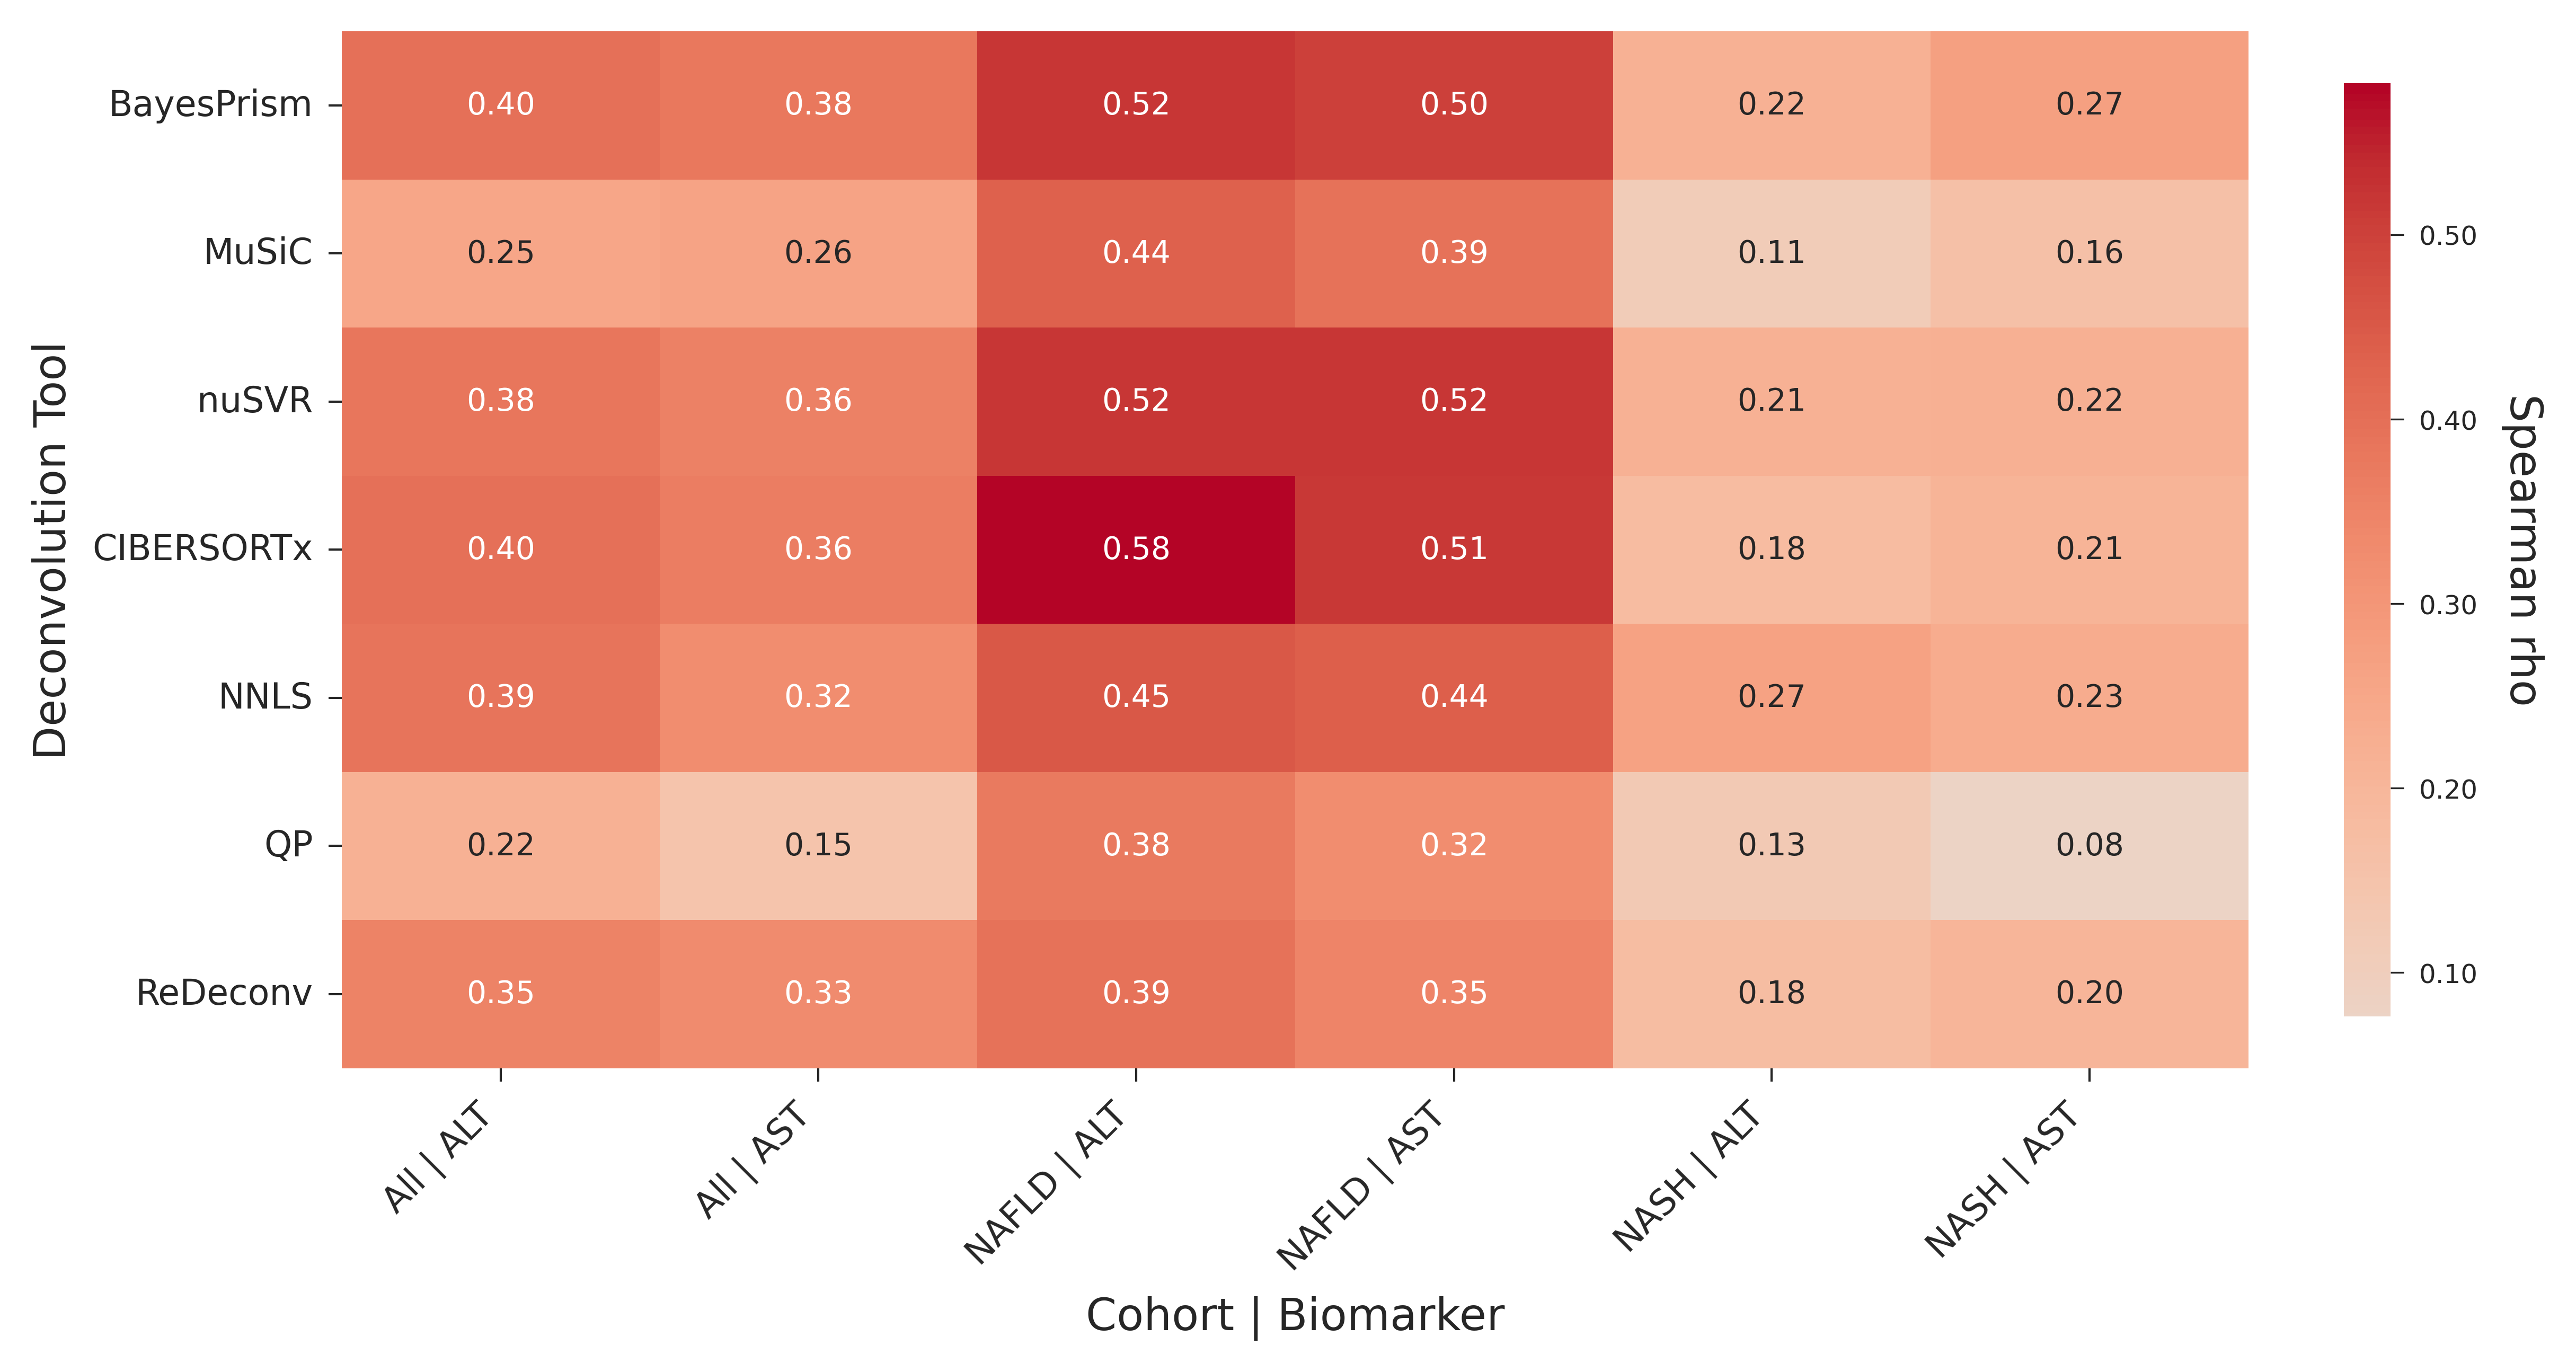

In [2]:
# =========================
# Heatmap: Liver vs ALT/AST correlations (by cohort)
# Uses output from the correlation script:
#   Results_Spearman-Corr/ALT_AST_Liver_correlations.csv  (tab-separated)
# =========================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'          # keep text as text in SVG
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
# --- Load correlation summary ---
base_out = "Results_Spearman-Corr"
corr_path = os.path.join(base_out, "ALT_AST_Liver_correlations.csv")
corr = pd.read_csv(corr_path, sep="\t")

# --- Choose which correlation metric to plot ---
# Options: "Spearman_rho" or "Pearson_r_log1p"
value_col = "Spearman_rho"

wanted = [
    ("All",   "AST"),
    ("All",   "ALT"),
    ("NAFLD", "AST"),
    ("NAFLD", "ALT"),
    ("NASH",  "AST"),
    ("NASH",  "ALT"),
]
corr = corr[corr.apply(lambda r: (r["Cohort"], r["Biomarker"]) in wanted, axis=1)].copy()

# --- Build a column label in the order you specified ---
label_map = {
    ("All",   "AST"):  "All | AST",
    ("All",   "ALT"):  "All | ALT",
    ("NAFLD", "AST"):  "NAFLD | AST",
    ("NAFLD", "ALT"):  "NAFLD | ALT",
    ("NASH",  "AST"):  "NASH | AST",
    ("NASH",  "ALT"):  "NASH | ALT",
}
corr["Panel"] = corr.apply(lambda r: label_map[(r["Cohort"], r["Biomarker"])], axis=1)

panel_order = [
    "All | ALT",
    "All | AST",
    "NAFLD | ALT",
    "NAFLD | AST",
    "NASH | ALT",
    "NASH | AST",
]

# --- Pivot to Tool × Panel ---
pivot_df = corr.pivot_table(
    index="DeconvolutionTool",
    columns="Panel",
    values=value_col,
    aggfunc="mean"
).reindex(columns=panel_order)

# --- Enforce preferred method order ---
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
present_order = [m for m in method_order if m in pivot_df.index]
remaining = [m for m in pivot_df.index if m not in present_order]
pivot_df = pivot_df.reindex(present_order + sorted(remaining))

# --- Plot heatmap in preferred style ---
sns.set(style="white")
fig, ax = plt.subplots(figsize=(8, 4.2), dpi=600, constrained_layout=True)

ax = sns.heatmap(
    pivot_df,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.9},
    linewidths=0,
    linecolor="white",
    center=0
)

# Force ticks to show (matching the other heatmaps style)
ax.tick_params(axis="x", which="both", bottom=True, top=False, labelbottom=True, length=3, width=0.5)
ax.tick_params(axis="y", which="both", left=True, right=False, labelleft=True, length=3, width=0.5)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Spearman rho", fontsize=10, rotation=270, labelpad=15)
cbar.ax.tick_params(labelsize=6, width=0.4, length=3)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

# Axes styling
plt.ylabel("Deconvolution Tool", fontsize=10)
plt.xlabel("Cohort | Biomarker", fontsize=10)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)

plt.show()


In [3]:
# =========================
# Heatmap: Liver vs ALT/AST correlations (by cohort)
# Uses output from the correlation script:
#   Results_Spearman-Corr/ALT_AST_Liver_correlations.csv  (tab-separated)
# =========================

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'          # keep text as text in SVG
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

# --- Load correlation summary ---
base_out = "Results_Spearman-Corr"
corr_path = os.path.join(base_out, "ALT_AST_Liver_correlations.csv")
corr = pd.read_csv(corr_path, sep="\t")

# --- Choose which correlation metric to plot ---
# Options: "Spearman_rho" or "Pearson_r_log1p"
value_col = "Spearman_rho"

wanted = [
    ("All",   "AST"),
    ("All",   "ALT"),
    ("NAFLD", "AST"),
    ("NAFLD", "ALT"),
    ("NASH",  "AST"),
    ("NASH",  "ALT"),
]
corr = corr[corr.apply(lambda r: (r["Cohort"], r["Biomarker"]) in wanted, axis=1)].copy()

# --- Build a column label in the order you specified ---
label_map = {
    ("All",   "AST"):  "All | AST",
    ("All",   "ALT"):  "All | ALT",
    ("NAFLD", "AST"):  "NAFLD | AST",
    ("NAFLD", "ALT"):  "NAFLD | ALT",
    ("NASH",  "AST"):  "NASH | AST",
    ("NASH",  "ALT"):  "NASH | ALT",
}
corr["Panel"] = corr.apply(lambda r: label_map[(r["Cohort"], r["Biomarker"])], axis=1)

panel_order = [
    "All | ALT",
    "All | AST",
    "NAFLD | ALT",
    "NAFLD | AST",
    "NASH | ALT",
    "NASH | AST",
]

# --- Pivot to Tool × Panel ---
pivot_df = corr.pivot_table(
    index="DeconvolutionTool",
    columns="Panel",
    values=value_col,
    aggfunc="mean"
).reindex(columns=panel_order)

# --- Enforce preferred method order ---
method_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
present_order = [m for m in method_order if m in pivot_df.index]
remaining = [m for m in pivot_df.index if m not in present_order]
pivot_df = pivot_df.reindex(present_order + sorted(remaining))

# --- Plot heatmap in preferred style ---
sns.set(style="white")
fig, ax = plt.subplots(figsize=(6, 4), dpi=600, constrained_layout=True)

ax = sns.heatmap(
    pivot_df,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.9},
    linewidths=0,
    linecolor="white",
    center=0
)

# Force ticks to show (matching the other heatmaps style)
ax.tick_params(axis="x", which="both", bottom=True, top=False, labelbottom=True, length=3, width=0.5)
ax.tick_params(axis="y", which="both", left=True, right=False, labelleft=True, length=3, width=0.5)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Spearman rho", fontsize=10, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=9, width=0.8, length=4)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

# Axes styling
plt.ylabel("Deconvolution Tool", fontsize=10, labelpad=10)
plt.xlabel("Cohort | Biomarker", fontsize=10, labelpad=10)

# ---- ADD n PER COHORT|BIOMARKER (x-axis labels) ----
n_per_panel = (
    corr.groupby("Panel")["N"]
    .first()  # N should be identical across tools within each Panel
    .reindex(pivot_df.columns)
)

new_xticklabels = [
    f"{panel}\n(n={int(n_per_panel[panel])})"
    if panel in n_per_panel.index and pd.notna(n_per_panel[panel])
    else panel
    for panel in pivot_df.columns
]
ax.set_xticklabels(new_xticklabels, rotation=45, ha="right", fontsize=9)
# ---------------------------------------------------

plt.yticks(fontsize=9)

out_path = os.path.join(base_out, "ALT_AST_Liver_correlations_heatmap.svg")
fig.savefig(out_path, format="svg")
plt.close(fig)